In [1]:
import os
import pickle
import matplotlib.pyplot as plt
import sys
import pandas as pd
internal_MPC_data_dir = os.getcwd()
internal_VTR_dir = os.path.abspath(os.path.join(internal_MPC_data_dir, '..', '..'))
root_dir = os.path.abspath(os.path.join(internal_VTR_dir, '..'))
internal_HT_dir = os.path.abspath(os.path.join(root_dir, '8_Hardware', 'Hardware_Testing'))
internal_HT_MPC_dir = os.path.abspath(os.path.join(internal_HT_dir, '2_MPC_Controllers'))
internal_scripts_dir = os.path.abspath(os.path.join(internal_HT_MPC_dir, 'scripts'))
sys.path.append(internal_scripts_dir)
import H_Common_Params as CP

In [2]:
internal_CDP_data_dir = os.path.abspath(os.path.join(internal_MPC_data_dir, 'Collected_Data_Python'))
print(internal_CDP_data_dir)

d:\lord_of_darkness\IITM\5th_year\Adaptive-Cruise-Control\9_Vehicle_Testing_Results\May_08\MPC\Collected_Data_Python


In [3]:
data_list = []
for i in range(len(os.listdir(internal_CDP_data_dir))):
    data_list.append(pd.read_csv(os.path.join(internal_CDP_data_dir, os.listdir(internal_CDP_data_dir)[i])))

In [4]:
data_list[-1].head()

,Ego_Position(m),Ego_Velocity(m/s),Obs_Position(m),Obs_Velocity(m/s),Time(s)
0,0.0,0.0,100,0,0.000007
1,0.0,0.0,100,0,0.005628
2,0.0,0.0,100,0,0.118368
3,0.0,0.0,100,0,0.228192
4,0.0,0.0,100,0,0.339311


In [5]:
def plot(ego_positions, ego_velocities, obs_positions, obs_velocities, times, detection_separation, title = 'Complete stopping (Scenario 3)'):
    font = 50
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (60, 25))
    
    plot_separations = [obs_positions[i] - ego_positions[i] for i in range(len(ego_positions))]
    plot_velocities = [ego_velocities[i] * 18 / 5 for i in range(len(ego_velocities))]
    index_1 = next((i for i, x in enumerate(plot_separations[1:]) if x < detection_separation), -1)
    
    ax1.plot(times, plot_separations, label = f'min : {round(min(plot_separations), 2)}, saturation : {round(plot_separations[-1], 2)}', linewidth = 4)
    ax1.plot(times[index_1:], [CP.Dd + CP.Td * Vego for Vego in ego_velocities[index_1:]], label = f'Desired final seperation : {round(CP.Dd + CP.Td * ego_velocities[-1], 2)}', color = 'green', linewidth = 6)
    ax1.axvline(x = times[index_1], color = 'black', linestyle = '--', label = 'Obstacle detected', linewidth = 4)
    ax1.grid(True, linewidth = 4)
    ax1.set_xlabel('Time [s]', fontsize = font, fontweight = 'bold')
    ax1.set_ylabel('Separation [m]', fontsize = font, fontweight = 'bold')
    ax1.set_title(title, fontsize = font, fontweight = 'bold')
    ax1.tick_params(axis = 'both', which = 'major', labelsize = font, width = 2)
    ax1.legend(fontsize = font)
    
    ax2.plot(times, plot_velocities, label = f'saturation : {round(plot_velocities[-1], 2)}, max : {round(max(plot_velocities), 2)}', linewidth = 4)
    ax2.plot(times[index_1:], [Vobs * 18 / 5 for Vobs in obs_velocities[index_1:]], label = f'Desired velocity : {round(obs_velocities[-1] * 18 / 5, 2)}', color = 'green', linewidth = 6)
    ax2.axvline(x = times[index_1], color = 'black', linestyle = '--', label = 'Obstacle detected', linewidth = 4)
    ax2.grid(True, linewidth = 4)
    ax2.set_xlabel('Time [s]', fontsize = font, fontweight = 'bold')
    ax2.set_ylabel('Velocity [km/hr]', fontsize = font, fontweight = 'bold')
    ax2.set_title(title, fontsize = font, fontweight = 'bold')
    ax2.tick_params(axis = 'both', which = 'major', labelsize = font, width = 2)
    ax2.legend(fontsize = font)
    
    plt.show()

In [6]:
titles = ['Cut in scenario (Scenario 1)', 'Complete stopping (Scenario 3)', 'Complete stopping (Scenario 3)']
detection_seperations = [20.0, 90.0, 90.0]

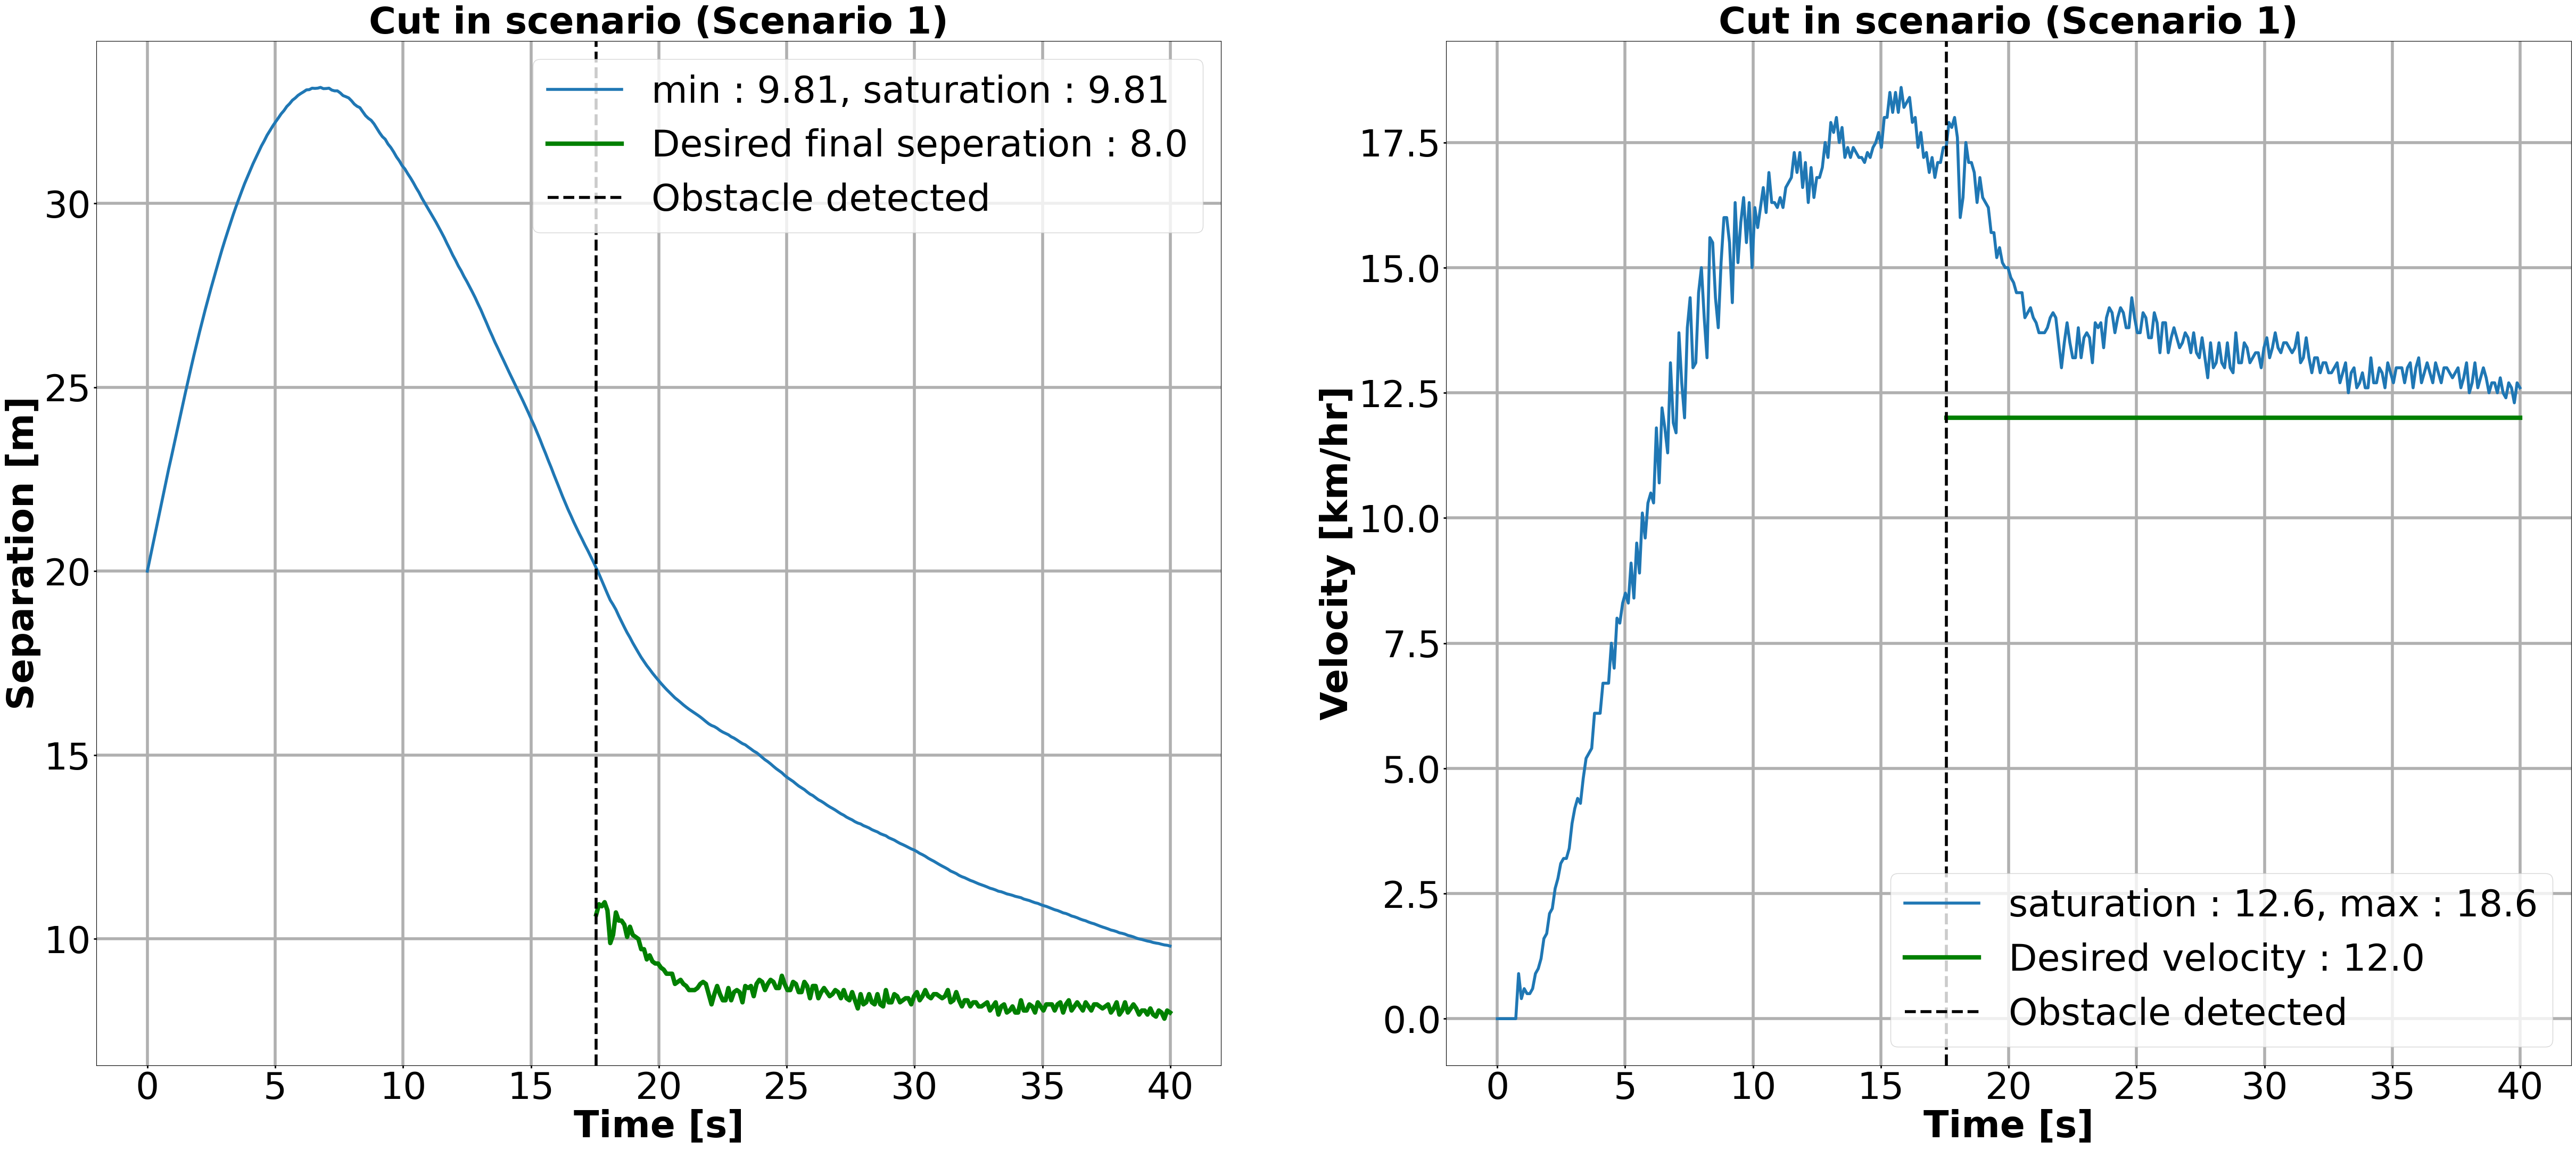

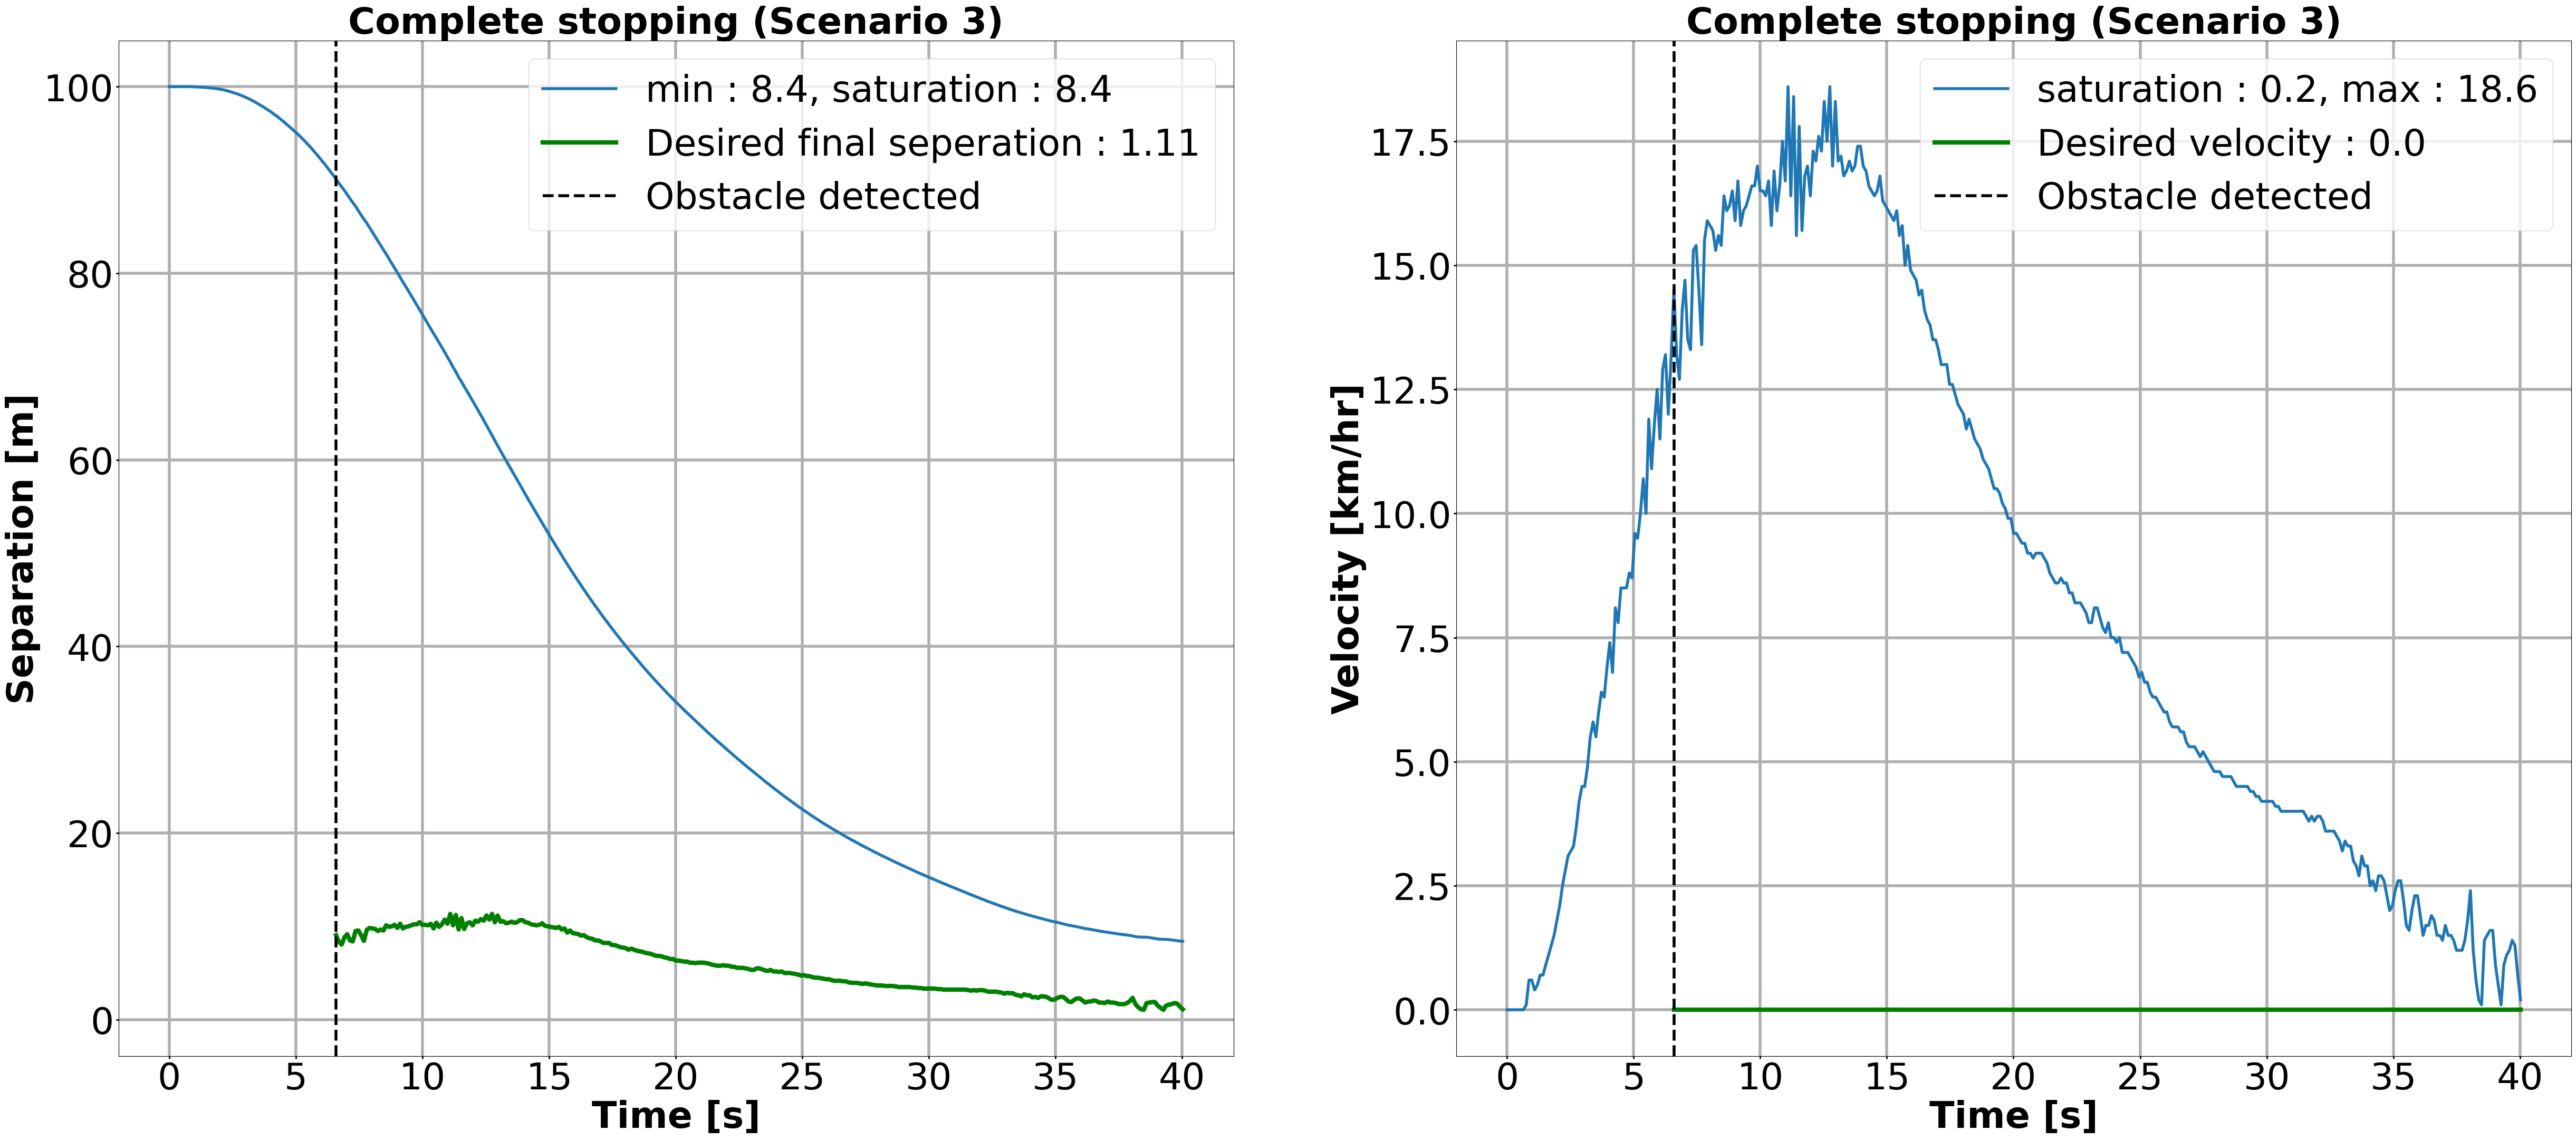

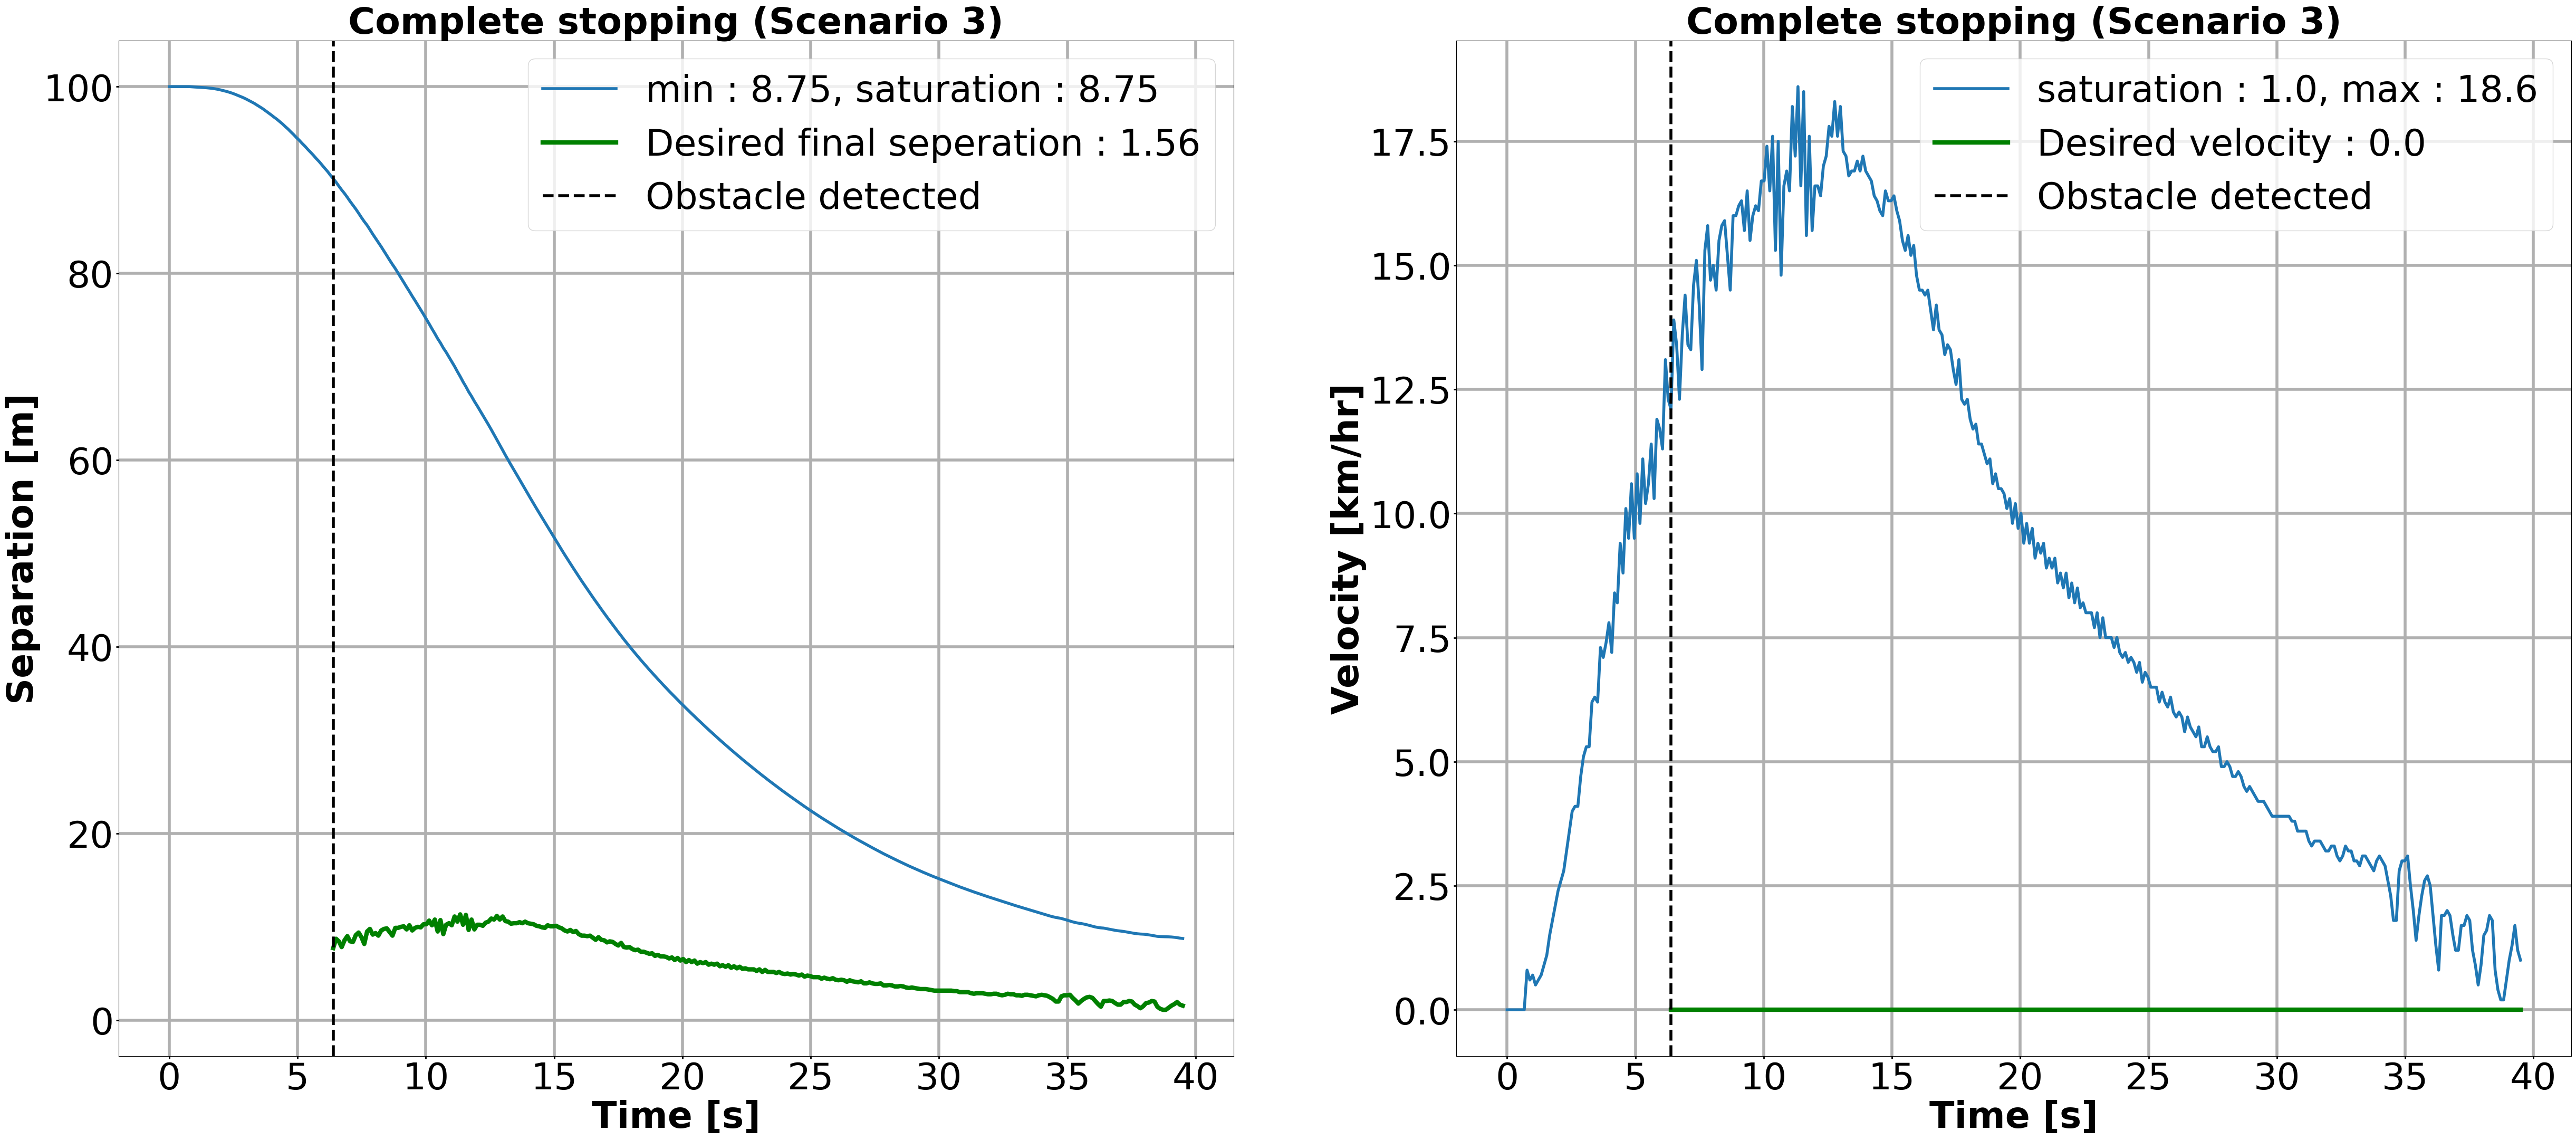

In [7]:
for i in range(len(data_list)):
    plot(list(data_list[i]['Ego_Position(m)']), list(data_list[i]['Ego_Velocity(m/s)']), list(data_list[i]['Obs_Position(m)']), list(data_list[i]['Obs_Velocity(m/s)']), list(data_list[i]['Time(s)']), detection_seperations[i], titles[i])